In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

col_names = ['engine_id', 'cycle',
             'setting1', 'setting2', 'setting3',
             's1','s2','s3','s4','s5','s6','s7',
             's8','s9','s10','s11','s12','s13',
             's14','s15','s16','s17','s18','s19',
             's20','s21']

SETTING_COLS   = ['setting1', 'setting2', 'setting3']
USEFUL_SENSORS = ['s2','s3','s4','s7','s8','s9','s11',
                  's12','s13','s14','s15','s17','s20','s21']
SUBSETS        = ['FD001', 'FD002', 'FD003', 'FD004']
DATA_DIR       = '../data/raw'
RUL_CAP        = 125
WINDOW_SIZE    = 30

print('Constants set.')
print(f'Useful sensors ({len(USEFUL_SENSORS)}):', USEFUL_SENSORS)

Constants set.
Useful sensors (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [11]:
FLAT_SENSORS = ['s1','s5','s6','s10','s16','s18','s19']

def load_raw(subset):
    kw = dict(sep=r'\s+', header=None, names=col_names, engine='python')
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt', **kw)
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',  **kw)
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt', header=None, names=['RUL'])
    train.drop(columns=FLAT_SENSORS, inplace=True)
    test.drop(columns=FLAT_SENSORS,  inplace=True)
    train[USEFUL_SENSORS] = train[USEFUL_SENSORS].astype(float)
    test[USEFUL_SENSORS]  = test[USEFUL_SENSORS].astype(float)
    return train, test, rul

data = {s: load_raw(s) for s in SUBSETS}

for subset, (train, test, rul) in data.items():
    print(f'{subset} — train: {train.shape}, test: {test.shape}, rul: {len(rul)}')

FD001 — train: (20631, 19), test: (13096, 19), rul: 100
FD002 — train: (53759, 19), test: (33991, 19), rul: 259
FD003 — train: (24720, 19), test: (16596, 19), rul: 100
FD004 — train: (61249, 19), test: (41214, 19), rul: 248


In [12]:
def add_rul(df):
    max_cycles = df.groupby('engine_id')['cycle'].max()
    df = df.copy()
    df['RUL'] = df['engine_id'].map(max_cycles) - df['cycle']
    df['RUL'] = df['RUL'].clip(upper=RUL_CAP)
    return df

for subset in SUBSETS:
    train, test, rul = data[subset]
    data[subset] = (add_rul(train), test, rul)

# Spot check
train_fd001, _, _ = data['FD001']
print('FD001 RUL range:', train_fd001['RUL'].min(), '—', train_fd001['RUL'].max())
train_fd002, _, _ = data['FD002']
print('FD002 RUL range:', train_fd002['RUL'].min(), '—', train_fd002['RUL'].max())

FD001 RUL range: 0 — 125
FD002 RUL range: 0 — 125


In [13]:
kmeans_models = {}  # subset -> fitted KMeans (None for single-condition subsets)

for subset in SUBSETS:
    train, test, rul = data[subset]
    train = train.copy()
    test  = test.copy()

    if subset in ['FD001', 'FD003']:
        # Single operating condition — one cluster, no KMeans needed
        train['cluster'] = 0
        test['cluster']  = 0
        kmeans_models[subset] = None
    else:
        # Fit KMeans on train settings only
        km = KMeans(n_clusters=6, random_state=42, n_init=10)
        train['cluster'] = km.fit_predict(train[SETTING_COLS])
        test['cluster']  = km.predict(test[SETTING_COLS])
        kmeans_models[subset] = km

    data[subset] = (train, test, rul)

# Verify cluster distribution for FD002
train_fd002, _, _ = data['FD002']
print('FD002 cluster counts:')
print(train_fd002['cluster'].value_counts().sort_index())

FD002 cluster counts:
cluster
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64


In [15]:
scalers = {}  # subset -> {cluster_id -> fitted scaler}

for subset in SUBSETS:
    train, test, rul = data[subset]
    train = train.copy()
    test  = test.copy()

    scalers[subset] = {}
    clusters = sorted(train['cluster'].unique())

    for cluster_id in clusters:
        train_mask = train['cluster'] == cluster_id
        test_mask  = test['cluster']  == cluster_id

        scaler = MinMaxScaler()

        # Fit ONLY on train rows for this cluster
        scaler.fit(train.loc[train_mask, USEFUL_SENSORS])

        # Transform train and test
        train.loc[train_mask, USEFUL_SENSORS] = scaler.transform(
            train.loc[train_mask, USEFUL_SENSORS]
        )
        test.loc[test_mask, USEFUL_SENSORS] = scaler.transform(
            test.loc[test_mask, USEFUL_SENSORS]
        )

        scalers[subset][cluster_id] = scaler

    data[subset] = (train, test, rul)
    print(f'{subset}: normalised {len(clusters)} cluster(s)')

# Save scalers + kmeans for production use later
with open('../models/multi_scalers.pkl', 'wb') as f:
    pickle.dump({'scalers': scalers, 'kmeans': kmeans_models}, f)
print('Scalers saved.')

FD001: normalised 1 cluster(s)
FD002: normalised 6 cluster(s)
FD003: normalised 1 cluster(s)
FD004: normalised 6 cluster(s)
Scalers saved.


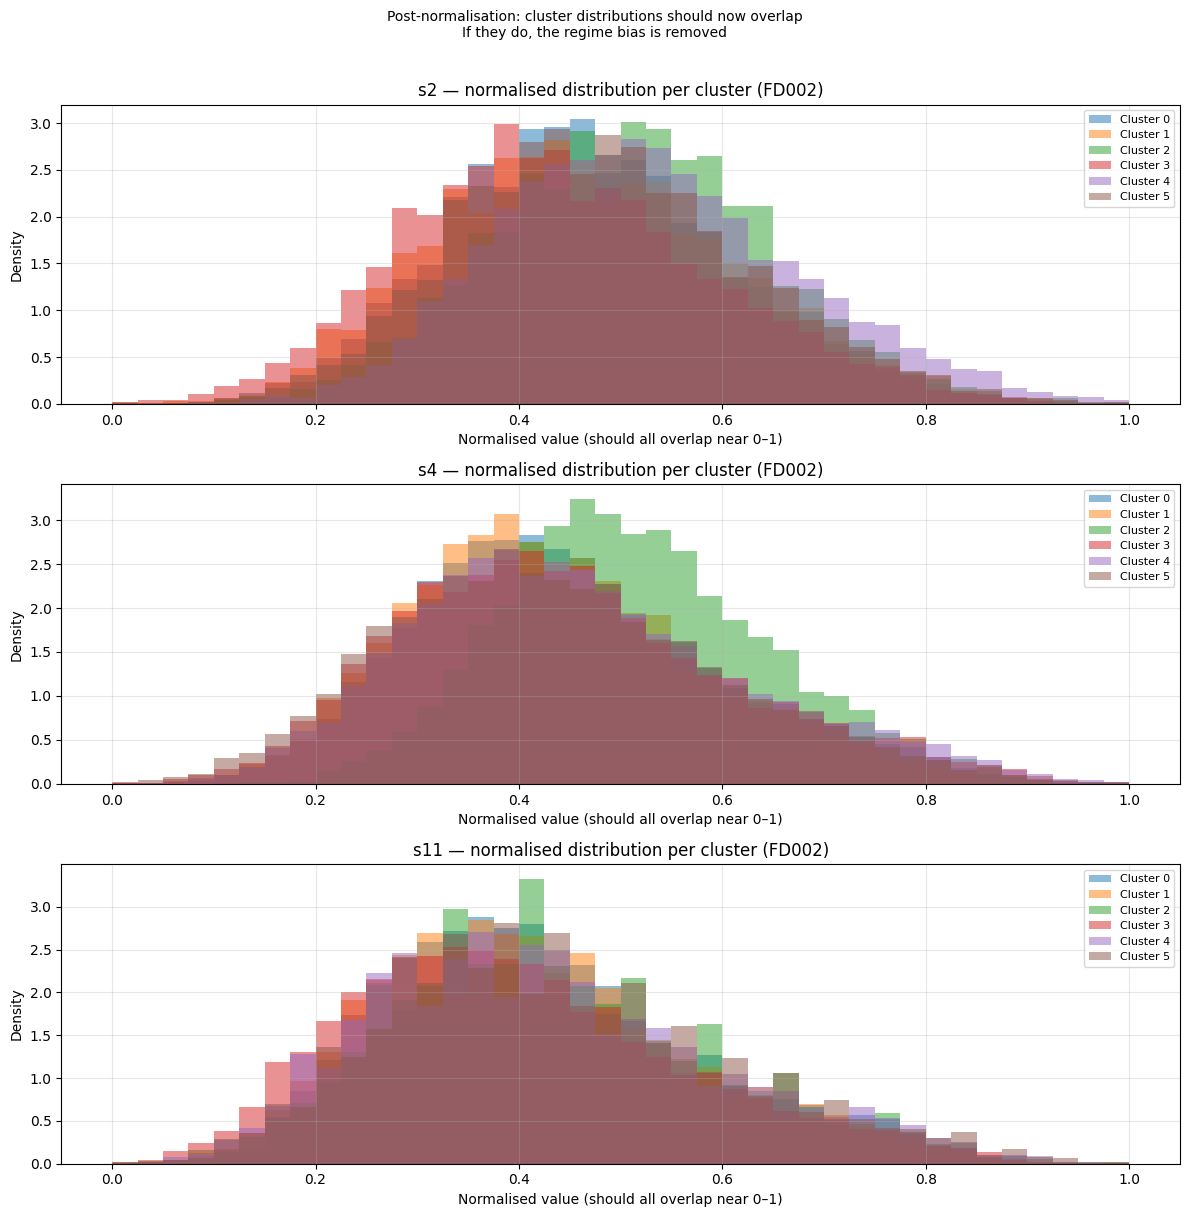

Normalised value ranges per sensor (FD002 train):
      s2   s3   s4   s7   s8   s9  s11  s12  s13  s14  s15  s17  s20  s21
min  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
max  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0


In [16]:
train_fd002, _, _ = data['FD002']
sensors_to_check  = ['s2', 's4', 's11']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, sensor in zip(axes, sensors_to_check):
    for cluster_id in sorted(train_fd002['cluster'].unique()):
        vals = train_fd002[train_fd002['cluster'] == cluster_id][sensor]
        ax.hist(vals, bins=40, alpha=0.5, label=f'Cluster {cluster_id}', density=True)
    ax.set_title(f'{sensor} — normalised distribution per cluster (FD002)')
    ax.set_xlabel('Normalised value (should all overlap near 0–1)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Post-normalisation: cluster distributions should now overlap\n'
             'If they do, the regime bias is removed', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

# Also check value ranges — all should be roughly 0 to 1
print('Normalised value ranges per sensor (FD002 train):')
print(train_fd002[USEFUL_SENSORS].agg(['min','max']).round(3).to_string())

In [17]:
def create_train_windows(df, window_size, sensors):
    X, y = [], []
    for engine_id in df['engine_id'].unique():
        eng = df[df['engine_id'] == engine_id].sort_values('cycle')
        sensor_vals = eng[sensors].values
        rul_vals    = eng['RUL'].values
        for i in range(len(eng) - window_size + 1):
            X.append(sensor_vals[i : i + window_size])
            y.append(rul_vals[i + window_size - 1])
    return np.array(X), np.array(y)

def create_test_windows(df, window_size, sensors):
    X = []
    for engine_id in df['engine_id'].unique():
        eng = df[df['engine_id'] == engine_id].sort_values('cycle')
        if len(eng) >= window_size:
            X.append(eng[sensors].values[-window_size:])
        else:
            # Engine shorter than window — pad with zeros at the front
            pad = np.zeros((window_size - len(eng), len(sensors)))
            X.append(np.vstack([pad, eng[sensors].values]))
    return np.array(X)

print('Window functions defined.')

Window functions defined.


In [18]:
train_windows = {}  # subset -> (X, y)

for subset in SUBSETS:
    train, _, _ = data[subset]
    X, y = create_train_windows(train, WINDOW_SIZE, USEFUL_SENSORS)
    train_windows[subset] = (X, y)
    print(f'{subset} — X: {X.shape}, y: {y.shape}')

FD001 — X: (17731, 30, 14), y: (17731,)
FD002 — X: (46219, 30, 14), y: (46219,)
FD003 — X: (21820, 30, 14), y: (21820,)
FD004 — X: (54028, 30, 14), y: (54028,)


In [19]:
test_windows = {}  # subset -> (X, y)

for subset in SUBSETS:
    _, test, rul = data[subset]

    X_test = create_test_windows(test, WINDOW_SIZE, USEFUL_SENSORS)

    # Cap test RUL at 125 — same ceiling as training
    y_test = rul['RUL'].values.clip(max=RUL_CAP)

    test_windows[subset] = (X_test, y_test)
    print(f'{subset} — X_test: {X_test.shape}, y_test: {y_test.shape}, '
          f'RUL range: {y_test.min():.0f}–{y_test.max():.0f}')

FD001 — X_test: (100, 30, 14), y_test: (100,), RUL range: 7–125
FD002 — X_test: (259, 30, 14), y_test: (259,), RUL range: 6–125
FD003 — X_test: (100, 30, 14), y_test: (100,), RUL range: 6–125
FD004 — X_test: (248, 30, 14), y_test: (248,), RUL range: 6–125


In [20]:
# Combined train
X_train_all = np.concatenate([train_windows[s][0] for s in SUBSETS], axis=0)
y_train_all = np.concatenate([train_windows[s][1] for s in SUBSETS], axis=0)

# Subset label per training sample — useful for debugging later
subset_labels = np.concatenate([
    np.full(len(train_windows[s][1]), i)
    for i, s in enumerate(SUBSETS)
])

print('Combined train:')
print(f'  X_train: {X_train_all.shape}')
print(f'  y_train: {y_train_all.shape}')
print(f'  Subset breakdown: { {s: len(train_windows[s][1]) for s in SUBSETS} }')

# Save combined
np.save('../data/X_train_multi.npy', X_train_all)
np.save('../data/y_train_multi.npy', y_train_all)
np.save('../data/subset_labels.npy', subset_labels)

# Save per-subset test arrays
for subset in SUBSETS:
    X_test, y_test = test_windows[subset]
    np.save(f'../data/X_test_{subset}.npy', X_test)
    np.save(f'../data/y_test_{subset}.npy', y_test)

print('All arrays saved.')

Combined train:
  X_train: (139798, 30, 14)
  y_train: (139798,)
  Subset breakdown: {'FD001': 17731, 'FD002': 46219, 'FD003': 21820, 'FD004': 54028}
All arrays saved.


In [21]:
print('=== FINAL SHAPE CHECK ===\n')

X = np.load('../data/X_train_multi.npy')
y = np.load('../data/y_train_multi.npy')
print(f'X_train_multi : {X.shape}  ← (samples, window, sensors)')
print(f'y_train_multi : {y.shape}')
print(f'RUL range     : {y.min():.0f} – {y.max():.0f}  (should be 0–125)')
print()

for subset in SUBSETS:
    X_test = np.load(f'../data/X_test_{subset}.npy')
    y_test = np.load(f'../data/y_test_{subset}.npy')
    print(f'{subset} test — X: {X_test.shape}, y: {y_test.shape}, '
          f'RUL range: {y_test.min():.0f}–{y_test.max():.0f}')

=== FINAL SHAPE CHECK ===

X_train_multi : (139798, 30, 14)  ← (samples, window, sensors)
y_train_multi : (139798,)
RUL range     : 0 – 125  (should be 0–125)

FD001 test — X: (100, 30, 14), y: (100,), RUL range: 7–125
FD002 test — X: (259, 30, 14), y: (259,), RUL range: 6–125
FD003 test — X: (100, 30, 14), y: (100,), RUL range: 6–125
FD004 test — X: (248, 30, 14), y: (248,), RUL range: 6–125
